In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


data = pd.read_csv(r'C:\Users\Vlad\PycharmProjects\ML\datasets\flights\Clean_Dataset.csv')
data.drop(['Unnamed: 0', 'flight'], axis=1, inplace=True)
data

,airline,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,Vistara,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,Vistara,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955
...,...,...,...,...,...,...,...,...,...,...
300148,Vistara,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,69265
300149,Vistara,Chennai,Afternoon,one,Night,Hyderabad,Business,10.42,49,77105
300150,Vistara,Chennai,Early_Morning,one,Night,Hyderabad,Business,13.83,49,79099
300151,Vistara,Chennai,Early_Morning,one,Evening,Hyderabad,Business,10.00,49,81585


### Обнаружение и визуализация данных для понимания их сущности

In [48]:
data.info()
print()
for column in data.columns:
    print(f'{column}: {data[column].nunique()}')

<class 'pandas.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   airline           300153 non-null  str    
 1   source_city       300153 non-null  str    
 2   departure_time    300153 non-null  str    
 3   stops             300153 non-null  str    
 4   arrival_time      300153 non-null  str    
 5   destination_city  300153 non-null  str    
 6   class             300153 non-null  str    
 7   duration          300153 non-null  float64
 8   days_left         300153 non-null  int64  
 9   price             300153 non-null  int64  
dtypes: float64(1), int64(2), str(7)
memory usage: 22.9 MB

airline: 6
source_city: 6
departure_time: 6
stops: 3
arrival_time: 6
destination_city: 6
class: 2
duration: 476
days_left: 49
price: 12157


In [49]:
conditions = [data['stops'] == 'zero', data['stops'] == 'one', data['stops'] == 'two_or_more']
choices = [0, 1, 2]
print(data['stops'].unique())
data['stops'] = np.select(conditions, choices, default=-1)

<StringArray>
['zero', 'one', 'two_or_more']
Length: 3, dtype: str


array([[<Axes: title={'center': 'stops'}>,
        <Axes: title={'center': 'duration'}>],
       [<Axes: title={'center': 'days_left'}>,
        <Axes: title={'center': 'price'}>]], dtype=object)

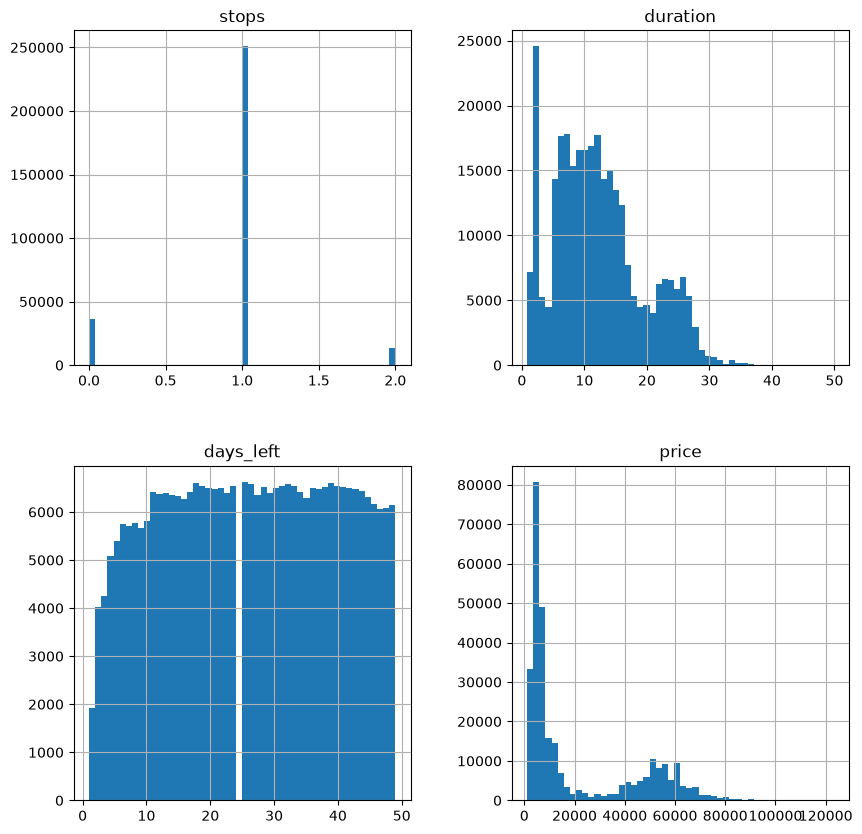

In [50]:
plt.style.use('default')
data.hist(bins=50, figsize=(10,10))

<Axes: xlabel='duration', ylabel='price'>

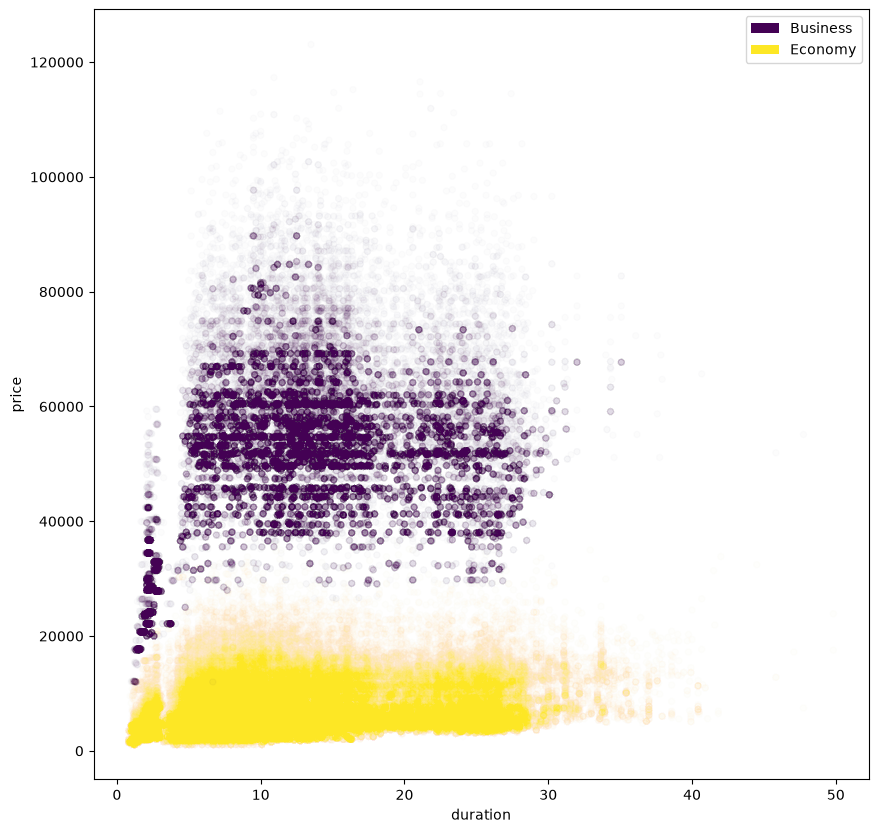

In [51]:
data.plot(kind='scatter', x='duration', y='price', alpha=0.01, c=data['class'], figsize=(10,10))

In [52]:
print(data)

         airline source_city departure_time  stops   arrival_time  \
0       SpiceJet       Delhi        Evening      0          Night   
1       SpiceJet       Delhi  Early_Morning      0        Morning   
2        AirAsia       Delhi  Early_Morning      0  Early_Morning   
3        Vistara       Delhi        Morning      0      Afternoon   
4        Vistara       Delhi        Morning      0        Morning   
...          ...         ...            ...    ...            ...   
300148   Vistara     Chennai        Morning      1        Evening   
300149   Vistara     Chennai      Afternoon      1          Night   
300150   Vistara     Chennai  Early_Morning      1          Night   
300151   Vistara     Chennai  Early_Morning      1        Evening   
300152   Vistara     Chennai        Morning      1        Evening   

       destination_city     class  duration  days_left  price  
0                Mumbai   Economy      2.17          1   5953  
1                Mumbai   Economy      2.33

## Эконом класс

In [53]:
data_econom = data[data['class'] == 'Economy']
data_econom = data_econom.drop(['class'], axis=1)

data_business = data[data['class'] == 'Business']
data_business = data_business.drop(['class'], axis=1)


array([[<Axes: title={'center': 'duration'}>,
        <Axes: title={'center': 'price'}>]], dtype=object)

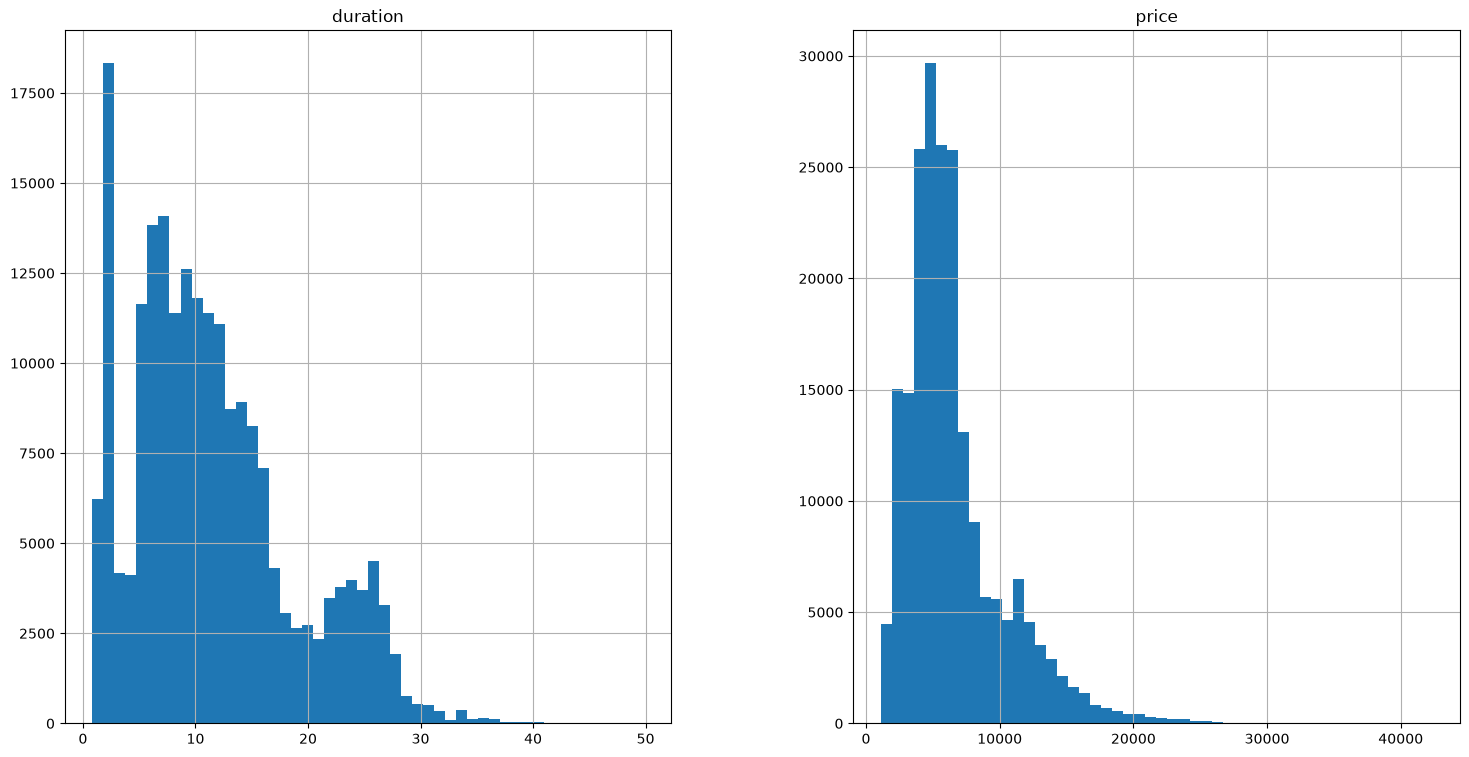

In [54]:
data_econom[['duration', 'price']].hist(bins=50, figsize=(18,9))

array([[<Axes: xlabel='duration', ylabel='duration'>,
        <Axes: xlabel='days_left', ylabel='duration'>,
        <Axes: xlabel='price', ylabel='duration'>],
       [<Axes: xlabel='duration', ylabel='days_left'>,
        <Axes: xlabel='days_left', ylabel='days_left'>,
        <Axes: xlabel='price', ylabel='days_left'>],
       [<Axes: xlabel='duration', ylabel='price'>,
        <Axes: xlabel='days_left', ylabel='price'>,
        <Axes: xlabel='price', ylabel='price'>]], dtype=object)

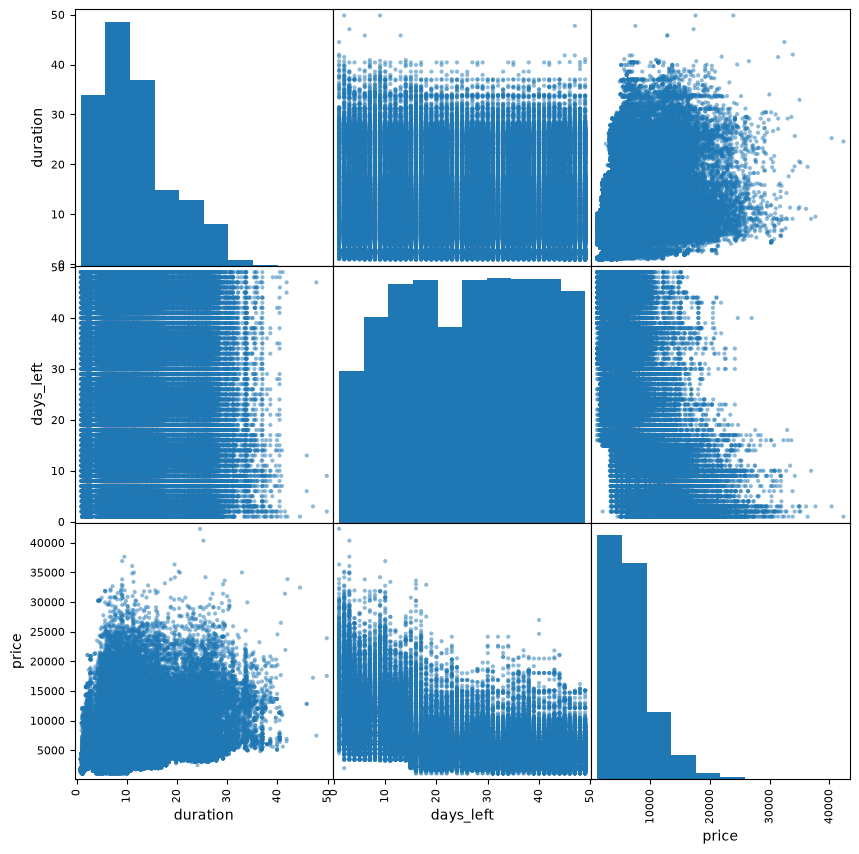

In [55]:
from pandas.plotting import scatter_matrix
scatter_matrix(data_econom[['duration', 'days_left', 'price']], figsize=(10, 10))

<Axes: xlabel='days_left', ylabel='price'>

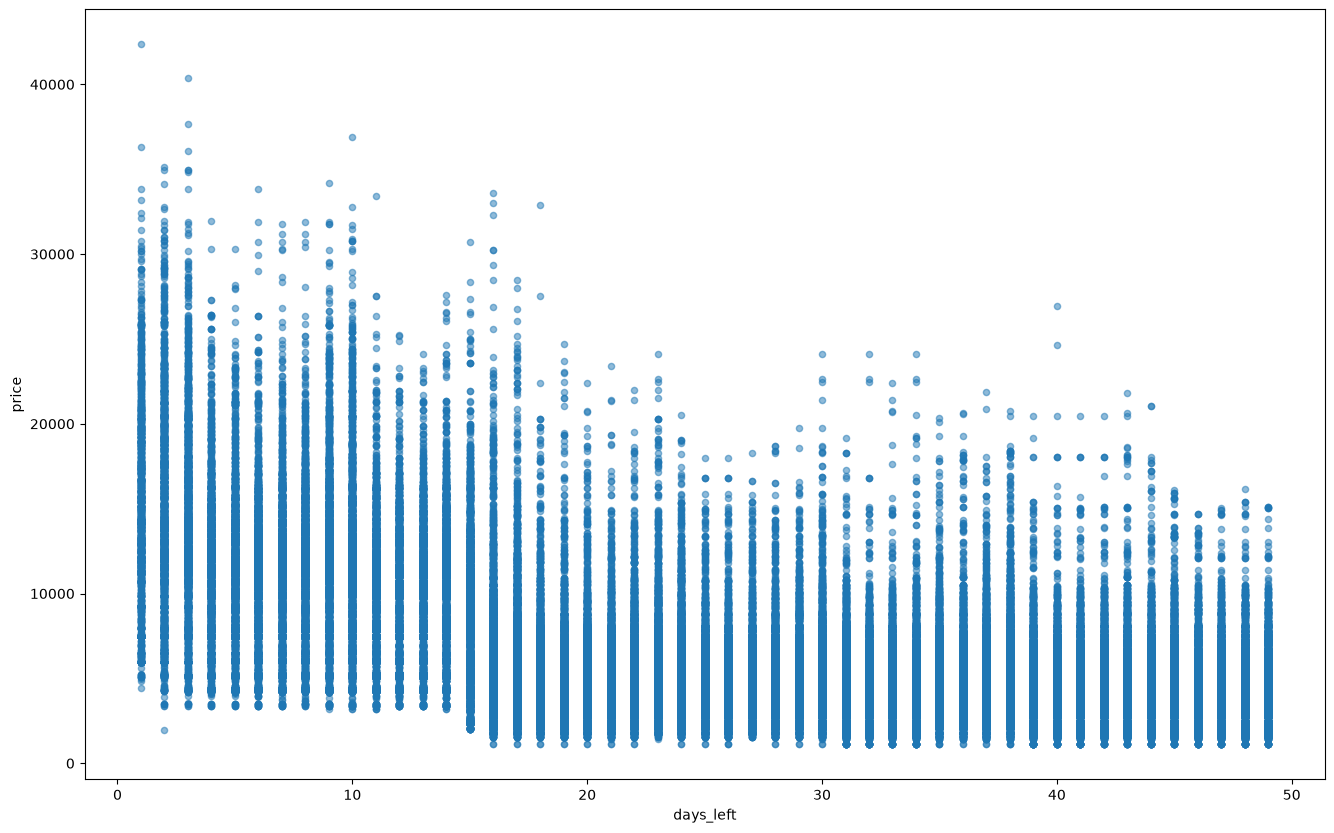

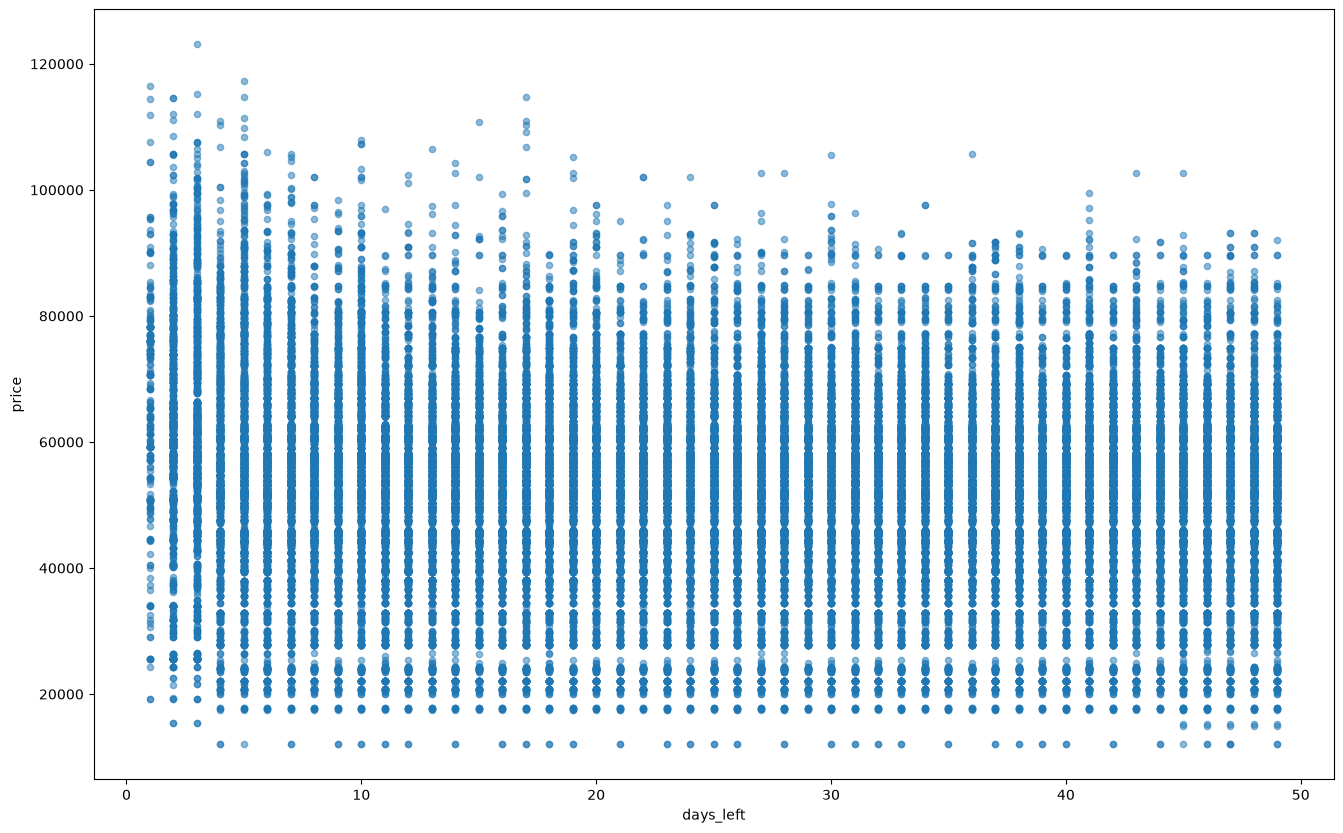

In [56]:
data_econom.plot(kind='scatter', x='days_left', y='price', alpha=0.5, figsize=(16,10))
data_business.plot(kind='scatter', x='days_left', y='price', alpha=0.5, figsize=(16,10))

In [57]:
days_left_econom = data_econom.groupby('days_left')['price'].agg('min').reset_index().rename(columns={'price': 'min_price'})
days_left_business = data_business.groupby('days_left')['price'].agg('min').reset_index().rename(columns={'price': 'min_price'})


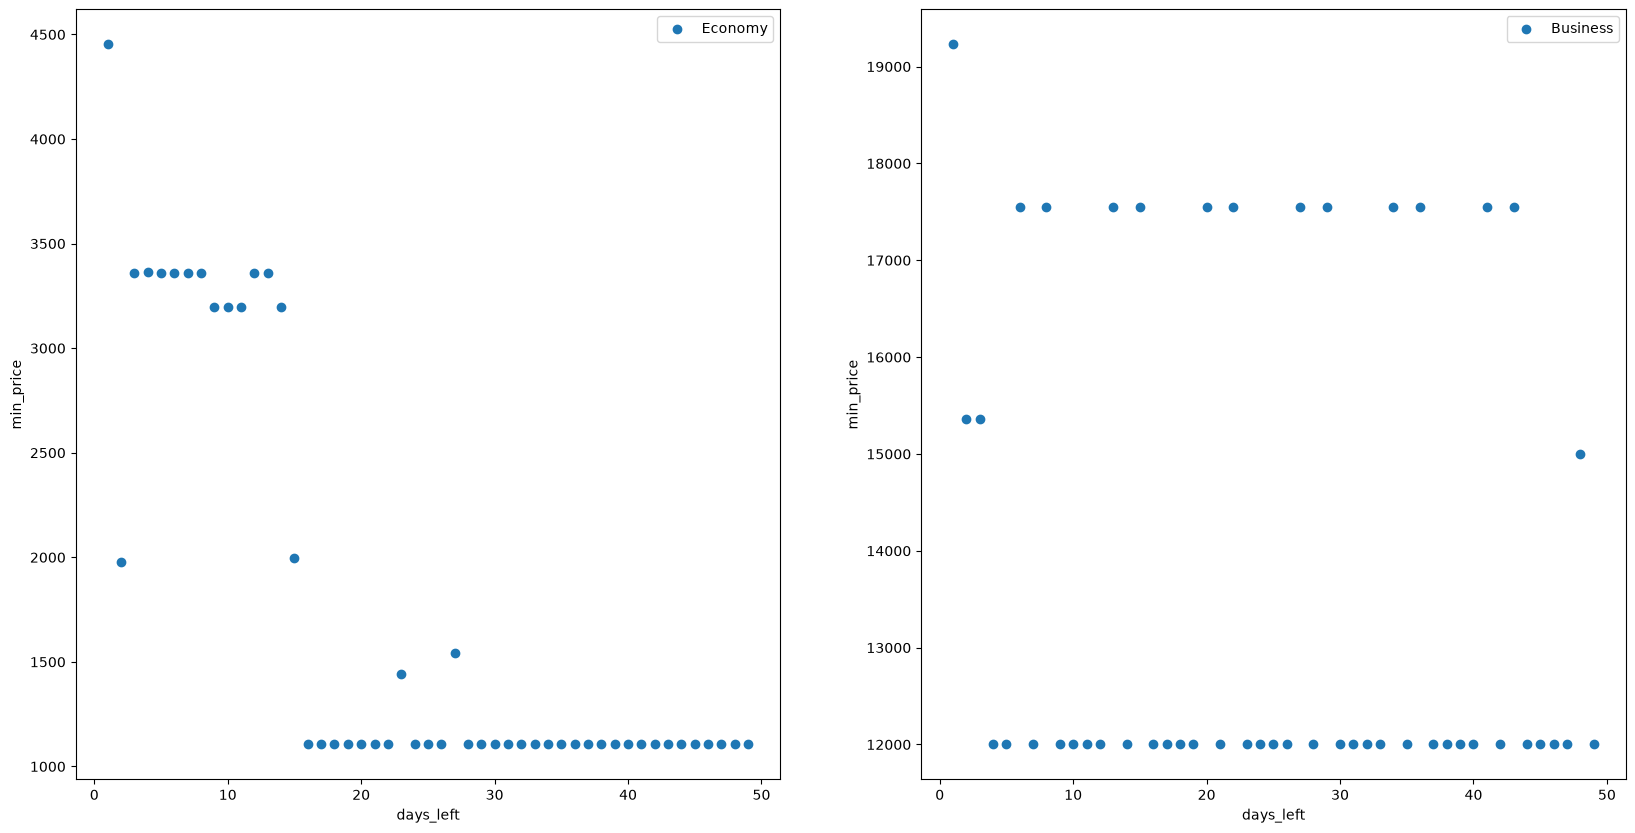

In [58]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(20,10))

ax[0].scatter(days_left_econom['days_left'], days_left_econom['min_price'], label='Economy')
ax[0].set_xlabel('days_left')
ax[0].set_ylabel('min_price')
ax[0].legend()

ax[1].scatter(days_left_business['days_left'], days_left_business['min_price'], label='Business')
ax[1].set_xlabel('days_left')
ax[1].set_ylabel('min_price')
ax[1].legend()

## Подготовка данных для алгоритмов машинного обучения

In [59]:
from sklearn.model_selection import train_test_split

econom_train, econom_test, econom_train_labels, econom_test_labels = train_test_split(data_econom.drop(['price'], inplace=False, axis=1), data_econom['price'], test_size=0.2, random_state=42)

In [60]:
from sklearn.base import TransformerMixin, BaseEstimator

class  days15(BaseEstimator, TransformerMixin):
    def __init__(self, add_feature=True):
        self.add_feature = add_feature

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        if self.add_feature:
            X_copy = X.copy()
            X_copy['days15'] = (X['days_left'] <= 15).astype(int)
            return X_copy
        else:
            return X

In [61]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ('one_hot', OneHotEncoder(sparse_output=False), ['airline', 'source_city', 'departure_time', 'arrival_time', 'destination_city'])
    ],
    remainder='passthrough'
)

In [62]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge

pipeline_linear = Pipeline([
    ('days15', days15()),
    ('preprocessor', preprocessor),
    ('regressor', Ridge(alpha=0.01, random_state=42))
])


In [63]:
pipeline_linear.fit(econom_train, econom_train_labels)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('days15', ...), ('preprocessor', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,add_feature,True
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('one_hot', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: flo

In [64]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(estimator=pipeline_linear, X=econom_train, y=econom_train_labels, cv=10, n_jobs=-1, scoring='neg_mean_absolute_error')
print(-scores)

[1565.01935351 1554.44605462 1575.84329118 1560.76511576 1594.34246483
 1569.34606245 1580.75929898 1580.53006975 1596.46813265 1573.27818498]


In [65]:
from sklearn.model_selection import GridSearchCV

param_grid = {'days15__add_feature': [False, True], 'regressor__alpha': [0, 0.01, 0.1, 1, 10]}
grid_search = GridSearchCV(estimator=pipeline_linear, param_grid=param_grid, cv=5, n_jobs=-1, scoring='neg_mean_absolute_error')

In [66]:
grid_search.fit(econom_train, econom_train_labels)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'days15__add_feature': [False, True], 'regressor__alpha': [0, 0.01, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_absolute_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Con

In [67]:
print(grid_search.best_params_)

scores = cross_val_score(estimator=grid_search.best_estimator_, X=econom_train, y=econom_train_labels, cv=10, n_jobs=-1, scoring='neg_mean_absolute_percentage_error')
print(-scores)

{'days15__add_feature': True, 'regressor__alpha': 0}
[0.2677979  0.26430154 0.2664936  0.26487366 0.26912573 0.26524929
 0.26546463 0.27037032 0.27023643 0.26241363]


## Поиск лучшей модели


In [86]:
from sklearn.ensemble import RandomForestRegressor

param_grid = {'regressor': [RandomForestRegressor(random_state=42)], 'regressor__n_estimators': [150, 200], 'regressor__max_depth': [20, 30]}
grid_search = GridSearchCV(param_grid=param_grid, estimator=pipeline_linear, cv=5, n_jobs=-1, scoring='neg_mean_absolute_error')

In [87]:
grid_search.fit(econom_train, econom_train_labels)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'regressor': [RandomForestR...ndom_state=42)], 'regressor__max_depth': [20, 30], 'regressor__n_estimators': [150, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_absolute_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable add

In [88]:
grid_search.best_params_

{'regressor': RandomForestRegressor(random_state=42),
 'regressor__max_depth': 30,
 'regressor__n_estimators': 200}

In [89]:
scores = cross_val_score(estimator=grid_search.best_estimator_, X=econom_train, y=econom_train_labels, cv=10, n_jobs=-1, scoring='neg_mean_absolute_percentage_error')
print(-scores)

[0.08633546 0.08760053 0.08629125 0.08804627 0.08644017 0.08706217
 0.08797657 0.08571989 0.08738368 0.08590486]
